In [ ]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import (
    TfidfVectorizer,
    ENGLISH_STOP_WORDS
)

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
import pandas as pd
df = pd.read_csv("../data/all_tickets_processed_improved_v3.csv")
print("Loaded")


Loaded


In [4]:
import os

print(os.path.exists("../data/all_tickets_processed_improved_v3.csv"))

True


In [5]:
 with open("../data/all_tickets_processed_improved_v3.csv", "r", encoding="utf-8") as f:
    for i in range(5):
        print(f.readline())

Document,Topic_group

connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead,Hardware

work experience user work experience user hi work experience student coming next his name much appreciate him duration thank,Access

requesting for meeting requesting meeting hi please help follow equipments cable pc cord plug,Hardware

reset passwords for external accounts re expire days hi ask help update passwords colleagues thank pm expire days importance high hi received about expiration please kindly help prolongation best regards pm expire days importance high dear expire days order change please follow steps prerequisites disable device credentials close active connected by cable machine note also follow steps detailed press ctrl alt delete same pops change item enter format enter enter newly chosen then re enter again submit displaying has changed os machine browse enter format enter gear icon top tight browser window enter enter newly

In [6]:
import pandas as pd

df = pd.read_csv(
    "../data/all_tickets_processed_improved_v3.csv"
)

print(df.shape)

(47837, 2)


In [7]:
df.columns

Index(['Document', 'Topic_group'], dtype='str')

In [8]:
df['Topic_group'].value_counts()

Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64

In [10]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)

In [11]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r'[^a-zA-Z ]',
        ' ',
        text
    )

    words = text.split()

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [12]:
df['clean_text'] = (
    df['Document']
    .apply(clean_text)
)

In [13]:
df[['Document','clean_text']].head()

,Document,clean_text
0,connection with icon icon dear please setup ic...,connection icon icon dear setup icon icon engi...
1,work experience user work experience user hi w...,work experience user work experience user hi w...
2,requesting for meeting requesting meeting hi p...,requesting meeting requesting meeting hi help ...
3,reset passwords for external accounts re expir...,reset passwords external accounts expire days ...
4,mail verification warning hi has got attached ...,mail verification warning hi got attached addr...


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    min_df=2,
    max_df=0.9,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(
    df['clean_text']
)

In [15]:
y = df['Topic_group']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
from sklearn.svm import LinearSVC

model = LinearSVC()

model.fit(
    X_train,
    y_train
)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [18]:
pred = model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score

print(
    "Accuracy:",
    accuracy_score(y_test, pred)
)

Accuracy: 0.8559782608695652


In [20]:
X.shape


(47837, 145149)

In [21]:
print(X.shape)

print(
    "Accuracy:",
    accuracy_score(y_test, pred)
)

(47837, 145149)
Accuracy: 0.8559782608695652


In [22]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred
    )
)

                       precision    recall  f1-score   support

               Access       0.92      0.89      0.90      1455
Administrative rights       0.84      0.73      0.78       342
           HR Support       0.85      0.85      0.85      2107
             Hardware       0.82      0.87      0.84      2760
     Internal Project       0.89      0.82      0.86       451
        Miscellaneous       0.82      0.83      0.82      1400
             Purchase       0.96      0.89      0.92       497
              Storage       0.92      0.87      0.89       556

             accuracy                           0.86      9568
            macro avg       0.88      0.84      0.86      9568
         weighted avg       0.86      0.86      0.86      9568



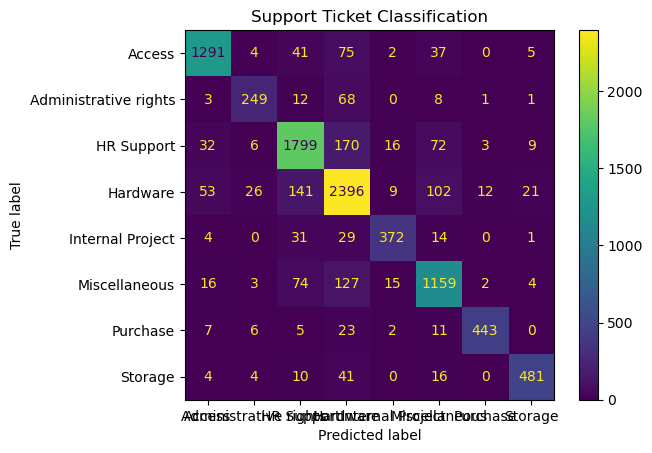

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred
)

plt.title(
    "Support Ticket Classification"
)

plt.show()

In [24]:
new_ticket = [
    "I forgot my password and cannot access my account"
]

new_ticket_clean = [
    clean_text(text)
    for text in new_ticket
]

new_ticket_vector = vectorizer.transform(
    new_ticket_clean
)

prediction = model.predict(
    new_ticket_vector
)

print(
    "Predicted Category:",
    prediction[0]
)

Predicted Category: Access
